In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
import random
import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)

<module 'MyHaloPS' from '/cosma/home/dp004/dc-zhan5/MyHaloPS.py'>

In [2]:
fontsize=12
boxsize = 205

In [3]:
snapnum = 40

In [4]:
base_dir = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/SubhaloFlag_all"
#ihalo_dir = f"{base_dir}/ihalo"
ihalo_dir = f"{base_dir}/mvir/ihalo"

### Read data for groups

In [5]:
#tng_dir3 = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/mvir/ihalo/rvir"
#tng_dir3 = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/ihalo"
tng_data_sum = np.loadtxt(f"{ihalo_dir}/sfr-halomass_sum.txt")


In [6]:
mask_min_sum = tng_data_sum[:,1] > 10
ihalo_tng_sum = tng_data_sum[:,0][mask_min_sum]
mhalo_tng_sum = tng_data_sum[:,1][mask_min_sum]
pos_tng_sum = tng_data_sum[:,2:5][mask_min_sum]
sfr_tng_sum = tng_data_sum[:,5][mask_min_sum]

Read zero SFR halos

In [7]:
tng_data_sum0 = np.loadtxt(f"{ihalo_dir}/sfr-halomass_sum.txt")

In [8]:
mask_min_sum0 = tng_data_sum0[:,1] > 10
ihalo_tng_sum0 = tng_data_sum0[:,0][mask_min_sum0]
mhalo_tng_sum0 = tng_data_sum0[:,1][mask_min_sum0]
pos_tng_sum0 = tng_data_sum0[:,2:5][mask_min_sum0]
sfr_tng_sum0 = tng_data_sum0[:,5][mask_min_sum0]

In [9]:
ihalo_tng3 = np.concatenate((ihalo_tng_sum, ihalo_tng_sum0))
mhalo_tng3 = np.concatenate((mhalo_tng_sum, mhalo_tng_sum0))
pos_tng3 = np.concatenate((pos_tng_sum, pos_tng_sum0))
sfr_tng3 = np.concatenate((sfr_tng_sum, sfr_tng_sum0))

Masks

In [10]:
mask = False
if mask is True:
    mask_min3 = (mhalo_tng3 > 10) & (pos_tng3[:,2] < 30) 
else:
    mask_min3 = mhalo_tng3 > 0

In [11]:
binned_all = ps.bin_data(ihalo_tng3, mhalo_tng3, pos_tng3, sfr_tng3)

dlogM =  0.1


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1824: RuntimeWarning: invalid value encountered in long_scalars
  hods.append(Nnonzero/Ntot)


### Invented relation

In [19]:
a1 = 1.8
b1 = -20.5
y = a1*12 + b1
print(y)
a2 = 0.7
b2 = y - a2*12
print(b2)
b2 = -7.3
print(b2)
y = a2*12 + b2
print(y)

1.1000000000000014
-7.299999999999997
-7.3
1.0999999999999988


In [20]:
poly_low = np.poly1d((a1,b1))
poly_high = np.poly1d((a2,b2))

In [24]:
import os


sfr_binned = binned_all["sfr"]
mhalo_binned = binned_all["mhalo"]
pos_binned = binned_all["pos"]

mhalos = np.concatenate(mhalo_binned)
pos = np.concatenate(pos_binned)
tng_sfrs = np.concatenate(sfr_binned)

sigma = False
sigma_low=0.4
sigma_high =0.2


if sigma is False:
    odir = f"/cosma8/data/dp004/dc-zhan5/invented/2sigma/{sigma_low}_{sigma_high}"
else:
    odir = f"/cosma8/data/dp004/dc-zhan5/invented/sigma{sigma}"
    sigma_low = sigma
    sigma_high = sigma
    
#odir1 = f"/cosma7/data/dp004/dc-zhan5/assignment_schemes/gaussian/tng_median/nonzero/sigma={sigma}"

is_tng_sfrs = False
is_mean = True
match_sfr_func = False

mhalo_change = 12

is_print = False

new_sfrs_list = []

if is_print:
    if not os.path.exists(odir):
        os.makedirs(odir)
        
shot_list = []
means_list = []

for fiducial_seed in range(0,1):
    np.random.seed(fiducial_seed)
    
    
    new_sfr_binned = []
    new_means = []
    new_mhalo_binned = []
    new_pos_binned = []
    
    
    
    #f_group = open(f"{odir}/logM<{logM}/seed{seed}.txt", "w")

    for ibin in range(len(mhalo_binned)):
        #sigma = stds[ibin]
        
        if len(mhalo_binned[ibin]) > 0:
            mask_low = mhalo_binned[ibin] < mhalo_change
            mask_high = mhalo_binned[ibin] > mhalo_change

            
            sfr_orig_low = np.random.normal(ps.Moster_sfr_mhalo(mhalo_binned[ibin][mask_low]), sigma_low)
            sfr_orig_high = np.random.normal(ps.Moster_sfr_mhalo(mhalo_binned[ibin][mask_high]), sigma_high)

            sfr_orig = np.concatenate((sfr_orig_low, sfr_orig_high))

            new_sfr_binned.append(sfr_orig)

           
            mean = np.log10(np.mean(10**sfr_orig))
            new_means.append(mean)
            
            new_mhalo_binned.append(np.concatenate((mhalo_binned[ibin][mask_low], mhalo_binned[ibin][mask_high])))
            new_pos_binned.append(np.concatenate((pos_binned[ibin][mask_low], pos_binned[ibin][mask_high])))

                
        else:
            new_means.append(np.nan)
            new_sfr_binned.append([])
            new_mhalo_binned.append([])
            new_pos_binned.append([])
   
    new_sfrs = np.concatenate(new_sfr_binned)
    shotnoise = ps.compute_shotnoise(10**new_sfrs, 205,3)
    shot_list.append(shotnoise)
    mean_sfr = np.mean(10**new_sfrs)
    means_list.append(mean_sfr)
    new_mhalos = np.concatenate(new_mhalo_binned)

    
    new_sfrs_list.append(new_sfrs)
    
    if match_sfr_func:
        sorted_new_sfr_indices = np.flip(np.argsort(new_sfrs)) 

        mhalos_renormed = mhalos[sorted_new_sfr_indices]
        pos_renormed = pos[sorted_new_sfr_indices]
        if is_tng_sfrs:
            sfrs_renormed = np.flip(np.sort(tng_sfrs))
        else:
            sfrs_renormed = np.array(new_sfrs)[sorted_new_sfr_indices]
        
        f_renormed = open(f"{odir}/match_sfr_func/seed{seed}.txt", "w")
        print("# log10(mass[Msun/h]) x[Mpc/h] y[Mpc/h] z[Mpc/h] log10(sfr[Msun/yr])", file=f_renormed)
      
        for ihalo in range(len(mhalos_renormed)):
            print(mhalos_renormed[ihalo], pos_renormed[ihalo][0], pos_renormed[ihalo][1], pos_renormed[ihalo][2], sfrs_renormed[ihalo], file=f_renormed)
        f_renormed.close()
    else:
        if is_mean:
            fname = f"{odir}/seed{fiducial_seed}_mean.txt"
        else:
            fname = f"{odir}/seed{fiducial_seed}.txt"
        
        if is_print:
            f_group = open(fname, "w")
            print("# log10(mass[Msun/h]) x[Mpc/h] y[Mpc/h] z[Mpc/h] log10(sfr[Msun/yr])", file=f_group)
 
            for ibin in range(len(mhalo_binned)):
                if len(sfr_binned[ibin]) > 0:
                    for ihalo in range(len(sfr_binned[ibin])):
                        if is_mean:
                            sfr = new_means[ibin]
                        else:
                            sfr = new_sfr_binned[ibin][ihalo]
                    
                        print(new_mhalo_binned[ibin][ihalo], new_pos_binned[ibin][ihalo][0], new_pos_binned[ibin][ihalo][1], new_pos_binned[ibin][ihalo][2], sfr , file=f_group)

            f_group.close()

      
    

In [503]:
def log2lin_sigma(log_mean, log_sigma):
    log_var = log_sigma**2
    lin_var = 10**(2*log_mean + 2*log_var*np.log(10)) - 10**(log_mean + 0.5*log_var*np.log(10))
    lin_sigma = np.sqrt(lin_var)
    return lin_sigma

In [522]:
log_std = np.std(new_sfrs02)
log_mean = np.mean(new_sfrs02)
print(log_std)
print(log_mean)

1.1487726633468296
-1.501453156912906


In [26]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2
from matplotlib.lines import Line2D

In [16]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list = palette_tab10

In [17]:
from curlyBrace import curlyBrace

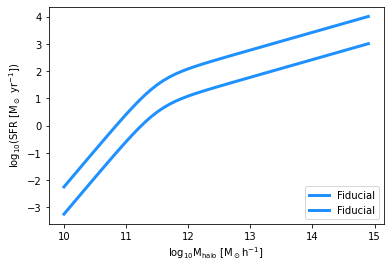

In [22]:
fig,ax = plt.subplots()
ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"]), label="Fiducial", color="DodgerBlue", linewidth=3)
ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"])+1, label="Fiducial", color="DodgerBlue", linewidth=3)
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.legend(loc="lower right")
plt.show()
plt.clf()
plt.close()

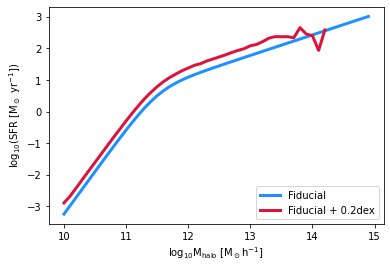

In [18]:
fig,ax = plt.subplots()
#plt.scatter(new_mhalos, new_sfrs, s=0.1,  color="skyblue", label="$\sigma$ = 0.2")
#ax.scatter(new_mhalos, new_sfrs, s=0.1,  color="salmon")
ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"]), label="Fiducial", color="DodgerBlue", linewidth=3)
ax.plot(binned_all["mass_bins"], new_means, label=f"Fiducial + 0.2dex", color="crimson", linewidth=3)
#ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"])+0.5, label="Estimated linear mean", color="blue", linewidth=1)



plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.legend(loc="lower right")
plt.show()
plt.cla()
plt.close()

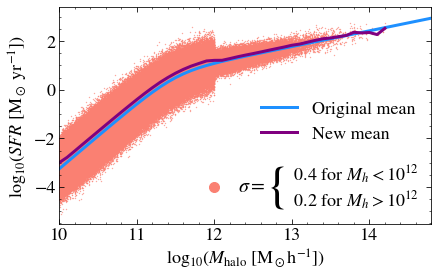

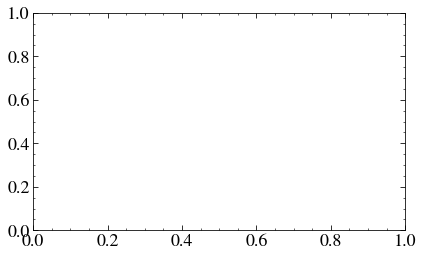

In [27]:
import matplotlib.transforms as mtrans
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch

fig,ax = plt.subplots()
#plt.scatter(new_mhalos, new_sfrs, s=0.1,  color="skyblue", label="$\sigma$ = 0.2")
ax.scatter(new_mhalos, new_sfrs, s=0.1,  color="salmon")



ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"]), label="Original mean", color="DodgerBlue", linewidth=3)

ax.plot(binned_all["mass_bins"], new_means, label="New mean", color="purple", linewidth=3)


legend = ax.legend(markerscale=30, loc="lower right",bbox_to_anchor=(1,0.3))




# ax.annotate(r"$\rm \sigma = $",fontsize=20,
#             xy=(0.55, 0.315), xycoords="figure fraction", textcoords=offset
#             )
ax.plot(12,-4, "o", markersize=10, c="salmon")
ax.annotate(r"$\sigma = $",fontsize=20,
            xy=(12.3,-4), va="center"
           )
ax.annotate(r"$\{$",fontsize=50,
            xy=(12.65, -4),  va="center"
           )
ax.annotate(r"$\rm \quad\quad\ 0.4\ for\ $" + "$M_h$" + "$ < 10^{12}$"+ "\n" +r"$\rm\quad\quad\ 0.2\ for\ $" + "$M_h$" + "$ > 10^{12}$",
            fontsize=18, xy=(12.6, -4), va="center"
           )

    
# offset = mpl.text.OffsetFrom(legend, (0.3, 0.33))
# ax.annotate(r"$\rm \sigma = $", xy=(1,1),size=20,
#             xycoords='figure fraction', xytext=(1,1), textcoords=offset,
#             horizontalalignment='right', verticalalignment='top')


def curly(x,y, scale, ax=None):
    if not ax: ax=plt.gca()
    tp = TextPath((0, 0), "{", size=1)
    trans = mtrans.Affine2D().scale(0.3, scale) + \
        mtrans.Affine2D().translate(x,y) + ax.transData
    pp = PathPatch(tp, lw=0, fc="k", transform=trans)
    ax.add_artist(pp)
#curly(12.8,-4.3,2, ax)




plt.xlabel(r"log$_{10}(M_{\rm halo}$ [M$_\odot$h$^{-1}$])")
plt.ylabel('log$_{10}$($SFR$ [M$_\odot$ yr$^{-1}$])')
plt.xlim(10,14.8)
#plt.savefig("../figures2/invented_sigma=0.4_0.2_orig_mean.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

In [218]:
orig_mean = ps.Moster_sfr_mhalo(np.concatenate(mhalo_binned))

In [266]:
bin_centers, bin_counts, errs = ps.luminosity_function(new_sfrs)

In [268]:
bin_centers1, bin_counts1, errs1 = ps.luminosity_function(new_sfrs)

In [ ]:
def sfr_from_bin_means_func(mass_bins, bin_means, mhalo):
    for mass in mass_bins:
        mass_bins = bin_means 
        

In [223]:
changed_mean = np.interp(np.concatenate(mhalo_binned), binned_all["mass_bins"], new_means)

In [ ]:
binned_all["mass_bins"], new_means

In [371]:
bin_centers2, bin_counts2, errs2 = ps.luminosity_function(new_sfrs)

In [376]:
bin_centers4, bin_counts4, errs4 = ps.luminosity_function(ps.Moster_sfr_mhalo(new_mhalos)+0.5*sigma**2*np.log(10))
bin_centers5, bin_counts5, errs5 = ps.luminosity_function(ps.Moster_sfr_mhalo(new_mhalos))

In [406]:
bin_centers4, bin_counts4, errs4 = ps.luminosity_function(ps.Moster_sfr_mhalo(new_mhalos))
bin_centers5, bin_counts5, errs5 = ps.luminosity_function(ps.Moster_sfr_mhalo(new_mhalos)+0.1)

In [407]:
bin_centers4, bin_counts6, errs4 = ps.luminosity_function(new_sfrs1)
bin_centers5, bin_counts7, errs5 = ps.luminosity_function(new_sfrs2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:8: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in log10
  if __name__ == '__main__':


Text(0, 0.5, 'log$_{10}$($\\phi$(SFR)  [h$^3$ cMpc$^{−3}$ dex$^{-1}$])')

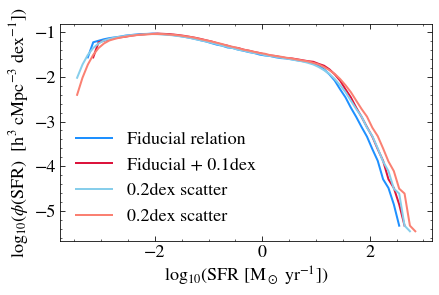

In [409]:

scatter = plt.plot(bin_centers4, np.log10(bin_counts4),label=r"Fiducial relation",  c="dodgerblue")

scatter = plt.plot(bin_centers5, np.log10(bin_counts5),label=r"Fiducial + 0.1dex",  c="crimson")



scatter = plt.plot(bin_centers4, np.log10(bin_counts6),label=r"0.2dex scatter",  c="skyblue")
scatter = plt.plot(bin_centers4, np.log10(bin_counts7),label=r"0.2dex scatter",  c="salmon")
plt.legend()
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"log$_{10}$($\phi$(SFR)  [h$^3$ cMpc$^{−3}$ dex$^{-1}$])")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in true_divide
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in true_divide
  """
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in true_divide
  """
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in true_divide
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in true_divide
  


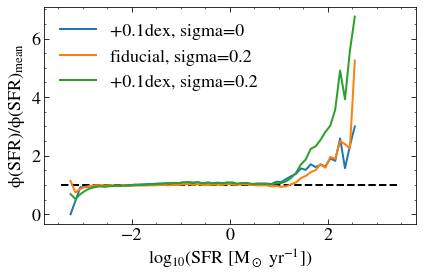

In [417]:
fig,ax = plt.subplots()

plt.plot([bin_centers3[0],bin_centers3[-1]], [1,1], c="k", linestyle="dashed")
plt.plot(bin_centers3, bin_counts5/bin_counts4, label="+0.1dex, sigma=0")
plt.plot(bin_centers3, bin_counts6/bin_counts4, label="fiducial, sigma=0.2")
plt.plot(bin_centers3, bin_counts7/bin_counts4, label="+0.1dex, sigma=0.2")
#plt.ylim(0.9,1.1)
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"$\rm \phi(SFR)/\phi(SFR)_{mean}$")
plt.legend()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in subtract
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log10
  """
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in subtract
  """
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  


Text(0, 0.5, 'log$_{10}$($\\phi$(SFR)  [h$^3$ cMpc$^{−3}$ dex$^{-1}$])')

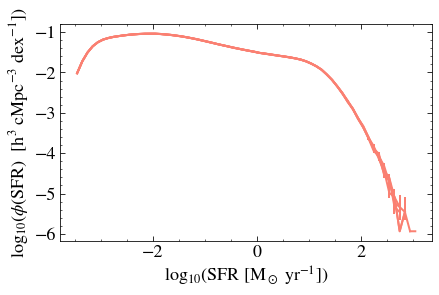

In [323]:
fig,ax = plt.subplots()
for sfrs in new_sfrs_list2:
    bin_centers2, bin_counts2, errs2 = ps.luminosity_function(sfrs)
    up_err = np.log10(bin_counts2 + errs2) - np.log10(bin_counts2)
    down_err = np.log10(bin_counts2) - np.log10(bin_counts2 - errs2)
    scatter = plt.errorbar(bin_centers2, np.log10(bin_counts2), yerr=[up_err, down_err],label=r"$\rm \sigma=0$",  c="salmon")

plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"log$_{10}$($\phi$(SFR)  [h$^3$ cMpc$^{−3}$ dex$^{-1}$])")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in true_divide
  # Remove the CWD from sys.path while we load stuff.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in true_divide
  # Remove the CWD from sys.path while we load stuff.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in true_divide
  # Remove the CWD from sys.path while we load stuff.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in true_divide
  # Remove the CWD from sys.path while we load stuff.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in true_divide
  # Remove the CWD from sys.path while we load stuff.


Text(0, 0.5, '$\\rm \\phi(SFR)/\\phi(SFR)_{mean}$')

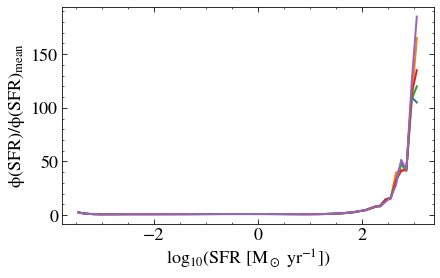

In [327]:
fig,ax = plt.subplots()
bin_counts_list = []
for sfrs in new_sfrs_list5:
    bin_centers3, bin_counts3, errs3 = ps.luminosity_function(sfrs)
    bin_counts_list.append(bin_counts3)

bin_counts_mean5 = np.mean(bin_counts_list,axis=0)

for counts in bin_counts_list:
    plt.plot(bin_centers3, counts/bin_counts_mean)
    
#plt.ylim(0.93,1.07)
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"$\rm \phi(SFR)/\phi(SFR)_{mean}$")

Text(0, 0.5, '$\\rm \\phi(SFR)/\\phi(SFR)_{mean}$')

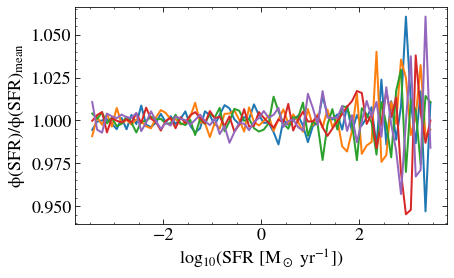

In [305]:
fig,ax = plt.subplots()
bin_centers2, bin_counts2, errs2 = ps.luminosity_function(new_sfrs_list[0])
bin_counts_list = []
for sfrs in new_sfrs_list:
    bin_centers3, bin_counts3, errs3 = ps.luminosity_function(sfrs)
    bin_counts_list.append(bin_counts3)

bin_counts_mean = np.mean(bin_counts_list,axis=0)

for counts in bin_counts_list:
    plt.plot(bin_centers3, counts/bin_counts_mean)
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"$\rm \phi(SFR)/\phi(SFR)_{mean}$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


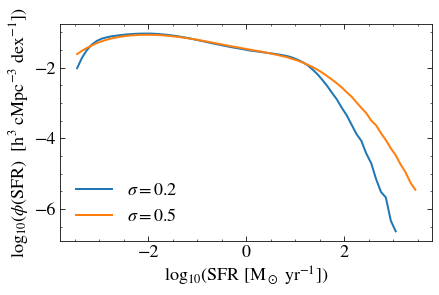

In [336]:
plt.plot(bin_centers2, np.log10(bin_counts_mean2), label="$\sigma=0.2$")
plt.plot(bin_centers2, np.log10(bin_counts_mean5), label="$\sigma=0.5$")
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"log$_{10}$($\phi$(SFR)  [h$^3$ cMpc$^{−3}$ dex$^{-1}$])")
plt.legend()

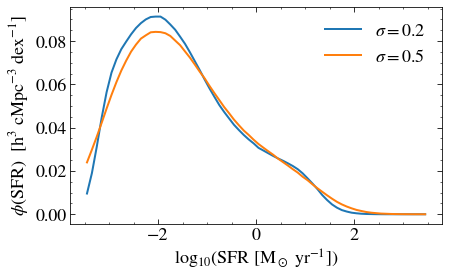

In [338]:
plt.plot(bin_centers2, bin_counts_mean2, label="$\sigma=0.2$")
plt.plot(bin_centers2, bin_counts_mean5, label="$\sigma=0.5$")
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"$\phi$(SFR)  [h$^3$ cMpc$^{−3}$ dex$^{-1}$]")
plt.legend()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in true_divide
  """Entry point for launching an IPython kernel.


Text(0.5, 0, 'log$_{10}$(SFR [M$_\\odot$ yr$^{-1}$])')

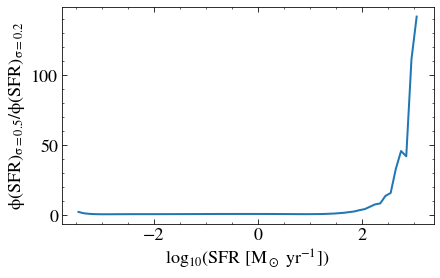

In [419]:
plt.plot(bin_centers2, bin_counts_mean5/bin_counts_mean2)
plt.ylabel(r"$\rm \phi(SFR)_{\sigma=0.5}/\phi(SFR)_{\sigma=0.2}$")
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')

Text(0.5, 0, 'log$_{10}$(SFR [M$_\\odot$ yr$^{-1}$])')

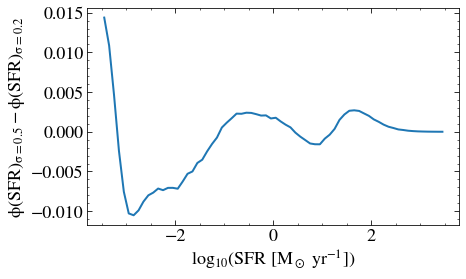

In [342]:
plt.plot(bin_centers2, bin_counts_mean5-bin_counts_mean2)
plt.ylabel(r"$\rm \phi(SFR)_{\sigma=0.5} - \phi(SFR)_{\sigma=0.2}$")
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in subtract
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in subtract
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in log10

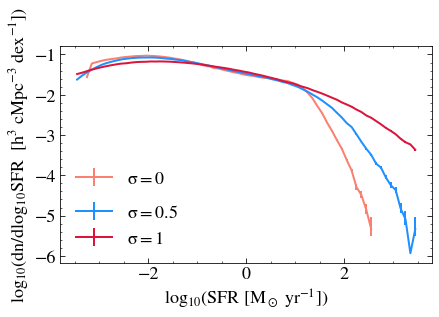

In [274]:
fig,ax = plt.subplots()
up_err = np.log10(bin_counts + errs) - np.log10(bin_counts)
down_err = np.log10(bin_counts) - np.log10(bin_counts - errs)
scatter = plt.errorbar(bin_centers, np.log10(bin_counts), yerr=[up_err, down_err],label=r"$\rm \sigma=0$",  c="salmon")

first_legend = plt.legend(loc="upper left", bbox_to_anchor=(0,0.5))
ax.add_artist(first_legend)

up_err = np.log10(bin_counts1 + errs1) - np.log10(bin_counts1)
down_err = np.log10(bin_counts1) - np.log10(bin_counts1 - errs1)
orig = plt.errorbar(bin_centers1, np.log10(bin_counts1), yerr=[up_err, down_err], label=r"$\rm \sigma=0.5$", c="DodgerBlue")


up_err = np.log10(bin_counts2 + errs2) - np.log10(bin_counts2)
down_err = np.log10(bin_counts2) - np.log10(bin_counts2 - errs2)
new = plt.errorbar(bin_centers2, np.log10(bin_counts2), yerr=[up_err, down_err], label=r"$\rm \sigma=1$", c="crimson")



# plt.annotate(r"$\sigma = $",fontsize=20,
#             xy=(-2.5,-4), va="center"
#            )
# plt.annotate(r"$\{$",fontsize=50,
#             xy=(-2, -4),  va="center"
#            )
# plt.annotate(r"$\rm \quad\quad\ 0.4\ for\ M_h < 10^{12}$"+ "\n" +r"$\rm\quad\quad\ 0.2\ for\ M_h > 10^{12}$",
#             fontsize=18, xy=(-2.1, -4), va="center"
#            )


plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"log$_{10}$(dn/dlog$_{10}$SFR  [h$^3$ cMpc$^{−3}$ dex$^{-1}$])")

plt.legend(handles=[orig,new])

#plt.savefig("../figures2/invented_sigma=0.4_0.2_new_mean_LF.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.clf()
plt.close()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in subtract
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in subtract
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in log10

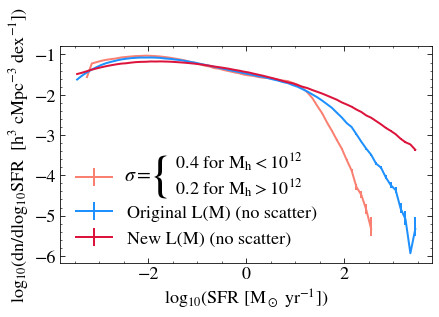

In [271]:
fig,ax = plt.subplots()
up_err = np.log10(bin_counts + errs) - np.log10(bin_counts)
down_err = np.log10(bin_counts) - np.log10(bin_counts - errs)
scatter = plt.errorbar(bin_centers, np.log10(bin_counts), yerr=[up_err, down_err],label=" ",  c="salmon")

first_legend = plt.legend(loc="upper left", bbox_to_anchor=(0,0.5))
ax.add_artist(first_legend)

up_err = np.log10(bin_counts1 + errs1) - np.log10(bin_counts1)
down_err = np.log10(bin_counts1) - np.log10(bin_counts1 - errs1)
orig = plt.errorbar(bin_centers1, np.log10(bin_counts1), yerr=[up_err, down_err], label="Original L(M) (no scatter)", c="DodgerBlue")


up_err = np.log10(bin_counts2 + errs2) - np.log10(bin_counts2)
down_err = np.log10(bin_counts2) - np.log10(bin_counts2 - errs2)
new = plt.errorbar(bin_centers2, np.log10(bin_counts2), yerr=[up_err, down_err], label="New L(M) (no scatter)", c="crimson")



plt.annotate(r"$\sigma = $",fontsize=20,
            xy=(-2.5,-4), va="center"
           )
plt.annotate(r"$\{$",fontsize=50,
            xy=(-2, -4),  va="center"
           )
plt.annotate(r"$\rm \quad\quad\ 0.4\ for\ M_h < 10^{12}$"+ "\n" +r"$\rm\quad\quad\ 0.2\ for\ M_h > 10^{12}$",
            fontsize=18, xy=(-2.1, -4), va="center"
           )


plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"log$_{10}$(dn/dlog$_{10}$SFR  [h$^3$ cMpc$^{−3}$ dex$^{-1}$])")

plt.legend(handles=[orig,new])

#plt.savefig("../figures2/invented_sigma=0.4_0.2_new_mean_LF.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.clf()
plt.close()

[  1.81493931 -20.6711927 ]
[-2.5     1.1075]
[-0.11240668  2.43139057]
[1.1075 1.989 ]


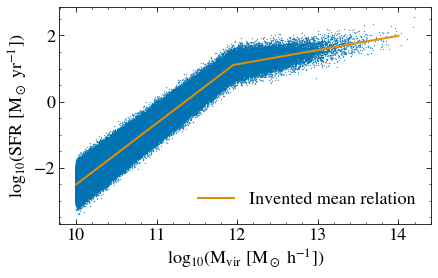

In [275]:
#plt.scatter(mhalo_tng3,sfr_tng3, s=0.1)
plt.scatter(np.concatenate(mhalo_binned), np.concatenate(shuffled_sfrs),s=0.1, color=color_list[0])
mask_low = (mhalo_tng3 < 11.95) & (sfr_tng3>-5)
poly = np.polyfit(mhalo_tng3[mask_low], sfr_tng3[mask_low], 1) 
print(poly)
f = np.poly1d((a1,b1))
x = [10,11.95]
y = f(x)
print(y)
plt.plot(x,y, c=color_list[1])

mask_low = (mhalo_tng3 > 11.95) & (sfr_tng3>0)
poly = np.polyfit(mhalo_tng3[mask_low], sfr_tng3[mask_low], 1) 
print(poly)
f = np.poly1d((a2,b2))
x = [11.95,14]
y = f(x)
print(y)
plt.plot(x,y, c=color_list[1])
solid_line = Line2D([],[],color=color_list[1], linestyle="solid", label="Invented mean relation")

plt.xlabel('log$_{10}$(M$_\mathrm{vir}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.legend(handles =[solid_line])
#plt.savefig("../figures2/invented_relation_scatter_0.2.png", format="png", dpi=300, bbox_inches="tight")
plt.clf()

In [76]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 5)
plt.rcParams["legend.frameon"] = False

Text(0, 0.5, 'log$_{10}$(SFR [M$_\\odot$ yr$^{-1}$])')

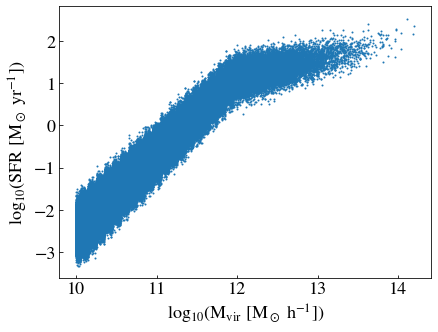

In [184]:
from matplotlib.lines import Line2D
color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.scatter(np.concatenate(mhalo_binned), np.concatenate(shuffled_sfrs),s=1)
#plt.scatter(np.concatenate(mhalo_binned), np.concatenate(polyfit_list),s=1)

solid_line = Line2D([],[],color=color_list[1], linestyle="solid", label="Best fit line")

plt.xlabel('log$_{10}$(M$_\mathrm{vir}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
#plt.legend(handles =[solid_line])
#plt.savefig("../figures2/sfr_mvir_polyfit_sigma0.5.pdf", format="pdf", bbox_inches="tight")

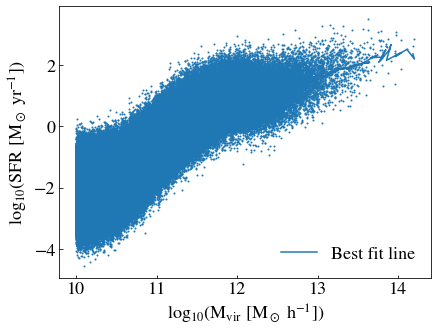

In [93]:
ibin = 40
plt.scatter(np.concatenate(mhalo_binned), np.concatenate(shuffled_sfrs),s=1)
plt.plot(np.concatenate(mhalo_binned), np.concatenate(polyfit_list), label="Best fit line")

plt.xlabel('log$_{10}$(M$_\mathrm{vir}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.legend()
#plt.savefig("../figures2/sfr_mvir_polyfit_sigma0.5.pdf", format="pdf", bbox_inches="tight")

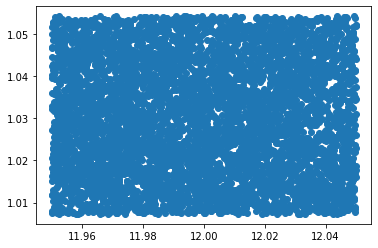

In [50]:
ibin = 40
plt.scatter(mhalo_binned[ibin], shuffled_sfrs[ibin])

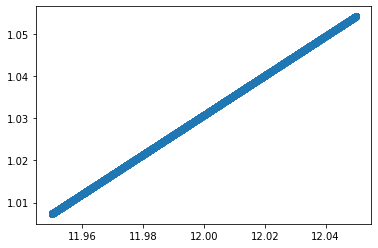

In [51]:
ibin = 40
plt.scatter(mhalo_binned[ibin], sfr_binned[ibin])

In [21]:
new_sat_mhalo

array([10.03750882, 10.01767318, 10.02153064, ..., 14.15249205,
       14.15249205, 14.15249205])

### Plot for number of halos in each bin

In [ ]:
mhalo_bins = [min(mhalo_tng)]
counts_binned = [0]
index = 0
for mhalo in mhalo_tng:
    if mhalo == mhalo_bins[-1]:
        counts_binned[index] += 1
    else:
        mhalo_bins.append(mhalo)
        index += 1
        counts_binned.append(1)

Text(0, 0.5, 'N$_{\\rm halos}$ in bin')

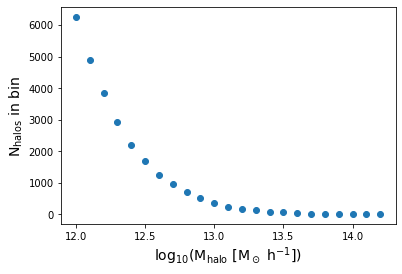

In [ ]:
fontsize=14
plt.scatter(mhalo_bins,counts_binned)
plt.xlabel('log$_{10}$(M$_\mathrm{halo}$ [M$_\odot$ h$^{-1}$])', fontsize=fontsize)
plt.ylabel(r'N$_{\rm halos}$ in bin', fontsize=fontsize)